# Shading probability regions

`Distribution.shade(lt=, le=, gt=, ge=)` shades a tail or interval under the most recently plotted curve. The bounds read as probability inequalities: `lt`/`le` set an upper bound (`X < lt` / `X <= le`), and `gt`/`ge` set a lower bound (`X > gt` / `X >= ge`). If you haven't plotted the distribution yet, `shade()` draws it for you first.

In [1]:
from symbulate import *

## A left tail

`shade()` auto-plots the curve first, so a one-liner works on a fresh distribution.

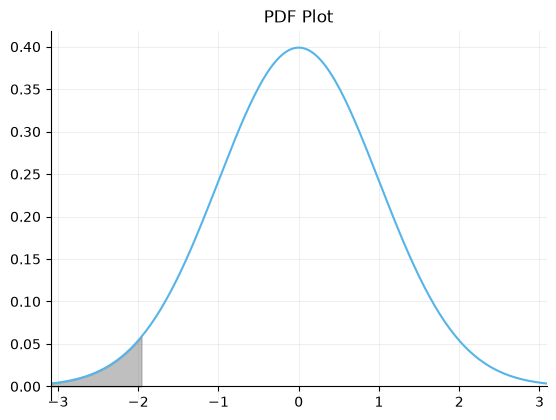

In [2]:
Normal(0, 1).shade(lt=-1.96)

## A right tail and an interval

One bound gives a tail; a lower and an upper bound together give an interval.

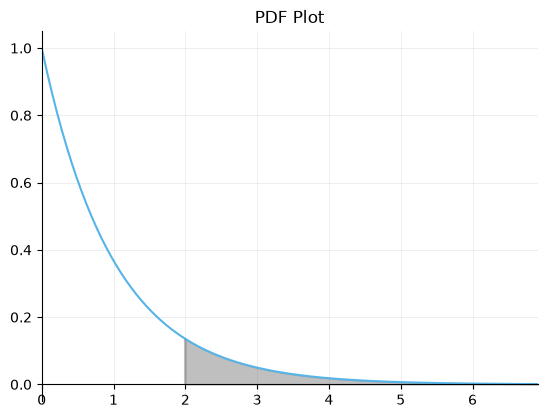

In [3]:
Exponential(1).shade(ge=2)

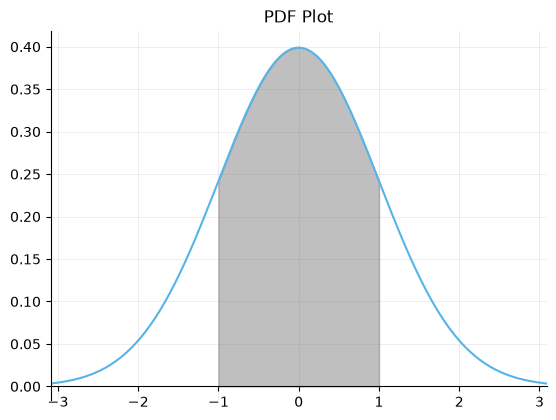

In [4]:
Normal(0, 1).shade(gt=-1, lt=1)

## Discrete: strict vs. inclusive

For a discrete distribution the strict (`lt`/`gt`) versus inclusive (`le`/`ge`) choice matters. `lt=3` leaves the mass at 3 out; `le=3` includes it.

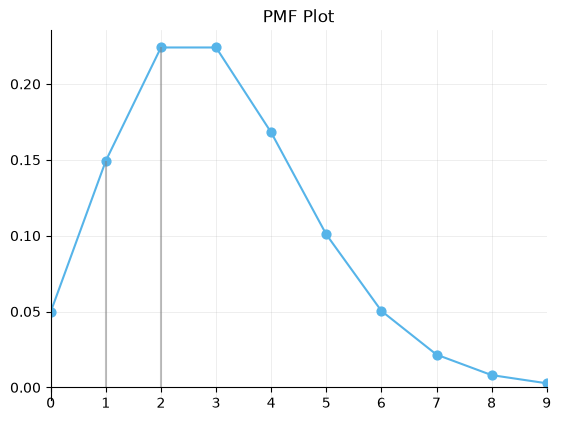

In [5]:
Poisson(3).shade(lt=3)  # 0, 1, 2

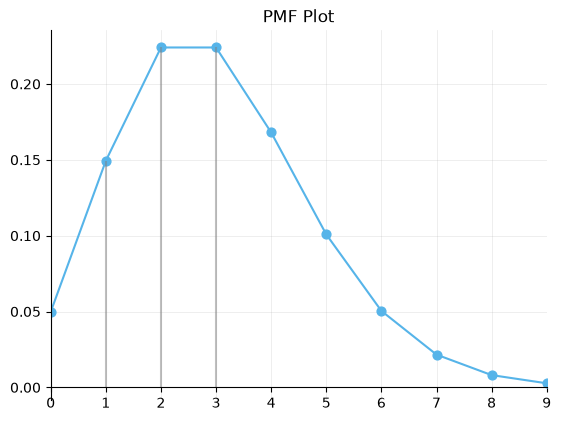

In [6]:
Poisson(3).shade(le=3)  # 0, 1, 2, 3

## A discrete interval

Mix the bounds freely: `gt=3, le=7` shades `3 < X <= 7`.

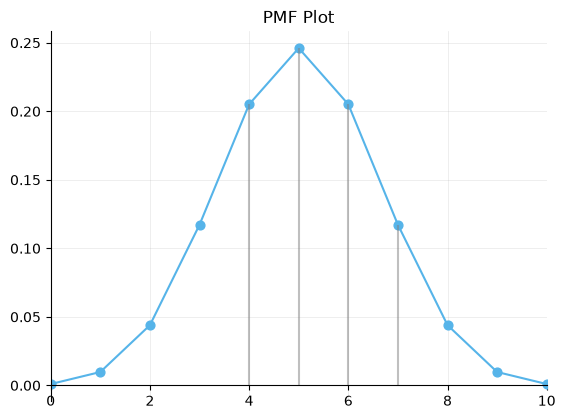

In [7]:
Binomial(10, 0.5).shade(gt=3, le=7)

### Why discrete regions look different from continuous ones

Notice the discrete plots shade the **vertical stems**, while continuous plots fill a solid **area**. That is intentional, and it reflects what "probability" means for each type:

- **Continuous:** probability is *area under the curve* — `P(a < X < b)` is the integral of the pdf, so the shaded area **is** the probability.
- **Discrete:** probability is *height, not area* — the pmf places mass **at** each integer, and there is **no probability between** integers. `P(X ∈ {0,1,2}) = pmf(0) + pmf(1) + pmf(2)`, a sum of heights.

So filling a solid area under a discrete distribution would shade the empty gaps between integers — regions that carry zero probability — and would wrongly imply the variable can take non-integer values. Shading the stems instead highlights exactly the masses being summed.

(The discrete **CDF** is the one exception: it *is* filled, because there the plotted object is a step function and filling under the steps is faithful to it.)

## Shade onto a curve you already drew

A second call draws on the same axes, so you can plot once and shade a region on top.

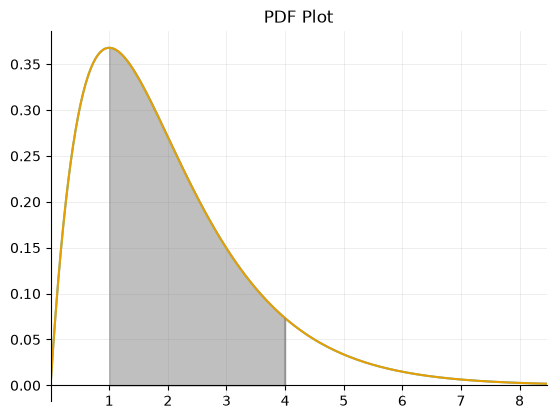

In [8]:
Gamma(2, 1).plot()
Gamma(2, 1).shade(gt=1, le=4)

## Respects the `prob=` window

The shaded region spans whatever x-window `plot()` produced. With `prob=`, the plot zooms to where the probability lives, and an open tail shades to that visible edge — not out to the distribution's full support.

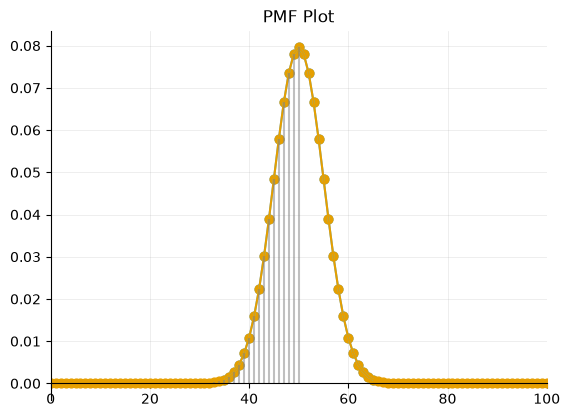

In [9]:
Binomial(100, 0.5).plot(prob=True)
Binomial(100, 0.5).shade(le=50)

## Shade under a CDF

`shade()` fills under whatever was last plotted, including a `type="cdf"` curve.

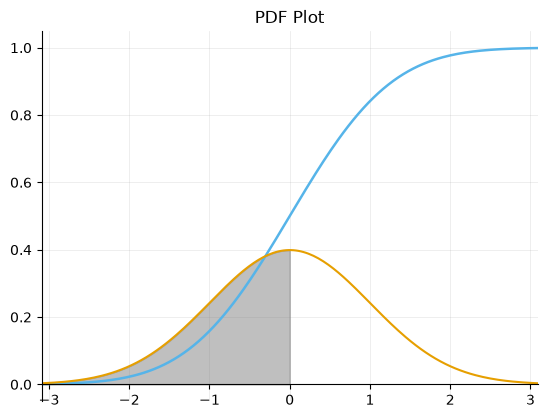

In [10]:
Normal(0, 1).plot(type="cdf")
Normal(0, 1).shade(lt=0)

---
## Summary of changes

**New method: `Distribution.shade(lt=, le=, gt=, ge=)`** — did not exist on `dev` before this work. It shades a tail or interval under the most recently plotted curve, auto-plotting the distribution first if needed.

| What | Detail |
|---|---|
| **Inequality interface** | Bounds read as probability inequalities: `lt`/`le` (upper, strict/inclusive), `gt`/`ge` (lower, strict/inclusive). Chosen over a plain `(from_x, to_x)` interval form because it expresses the open-vs-closed endpoint distinction that matters for discrete distributions. |
| **Discrete vs. continuous rendering** | Continuous → filled area under the curve (area = probability). Discrete → shaded impulses at the integer values (probability is height/mass, not area). |
| **Respects the displayed window** | Shading bounds come from the *actual* plotted x-axis, so open tails honor `prob=`, custom `xlim=`, and overlays. The reference fork we ported from predates `prob=` and always used the full default support. |
| **Works on pmf, pdf, and CDF** | Shades under whichever curve was last plotted, including `type="cdf"`. |
| **Student-friendly errors** | Clear messages for conflicting bounds (`lt` with `le`, `gt` with `ge`) or a lower bound not below the upper bound. |

Implemented in `symbulate/distributions.py` (method + a `plotted`/`_last_plot_type` tracking flag), with shade color/alpha as named constants in `symbulate/plot.py` and 15 new tests in `symbulate/tests/test_distributions.py`.